In [9]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
nltk.download("stopwords")
nltk.download('punkt')
nltk.download('wordnet')
from nltk.stem import PorterStemmer , WordNetLemmatizer

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\INTEL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\INTEL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\INTEL\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


# Movie dataset details 


In [10]:
movies = pd.read_csv("movies_metadata.csv")
keywords =pd.read_csv("keywords.csv")

C:\Users\INTEL\AppData\Local\Temp\ipykernel_1548\1972539539.py:1: DtypeWarning: Columns (10) have mixed types. Specify dtype option on import or set low_memory=False.
  movies = pd.read_csv("movies_metadata.csv")


In [11]:
movies.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [12]:
keywords.head()

,id,keywords
0,862,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,8844,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,15602,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,31357,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,11862,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."


In [13]:
movies.shape

(45466, 24)

In [14]:
movies.columns

Index(['adult', 'belongs_to_collection', 'budget', 'genres', 'homepage', 'id',
       'imdb_id', 'original_language', 'original_title', 'overview',
       'popularity', 'poster_path', 'production_companies',
       'production_countries', 'release_date', 'revenue', 'runtime',
       'spoken_languages', 'status', 'tagline', 'title', 'video',
       'vote_average', 'vote_count'],
      dtype='object')

In [15]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [16]:
movies.describe()

,revenue,runtime,vote_average,vote_count
count,4.546000e+04,45203.000000,45460.000000,45460.000000
mean,1.120935e+07,94.128199,5.618207,109.897338
std,6.433225e+07,38.407810,1.924216,491.310374
min,0.000000e+00,0.000000,0.000000,0.000000
25%,0.000000e+00,85.000000,5.000000,3.000000
50%,0.000000e+00,95.000000,6.000000,10.000000
75%,0.000000e+00,107.000000,6.800000,34.000000
max,2.787965e+09,1256.000000,10.000000,14075.000000


# Hold important columns

In [17]:
movies = movies[['id','title','overview','genres','vote_average','popularity']]

# Handling nan and duplicated values 

In [18]:
movies.isna().sum()


id                0
title             6
overview        954
genres            0
vote_average      6
popularity        5
dtype: int64

in the "Overview" column see there are 954 nan values present where title holds 6 and vote_average takes 6 aloneside popularity holes 5

In [19]:
movies.dropna(subset=['title'], inplace=True)

In [20]:
movies.isna().sum()

id                0
title             0
overview        954
genres            0
vote_average      0
popularity        0
dtype: int64

In [21]:
movies.duplicated().sum()

13

handling nan values using ''

In [22]:
movies['overview'] = movies['overview'].fillna('')

In [23]:
movies.drop_duplicates(inplace=True)

# Convert id 

In [24]:
movies = movies[movies['id'].str.isnumeric()]

movies['id'] = movies['id'].astype(int)

keywords['id'] = keywords['id'].astype(int)

# Merge dataset

In [25]:
movies = movies.merge(keywords,on='id')

movies.head()

,id,title,overview,genres,vote_average,popularity,keywords
0,862,Toy Story,"Led by Woody, Andy's toys live happily in his ...","[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",7.7,21.946943,"[{'id': 931, 'name': 'jealousy'}, {'id': 4290,..."
1,8844,Jumanji,When siblings Judy and Peter discover an encha...,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",6.9,17.015539,"[{'id': 10090, 'name': 'board game'}, {'id': 1..."
2,15602,Grumpier Old Men,A family wedding reignites the ancient feud be...,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",6.5,11.7129,"[{'id': 1495, 'name': 'fishing'}, {'id': 12392..."
3,31357,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...","[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",6.1,3.859495,"[{'id': 818, 'name': 'based on novel'}, {'id':..."
4,11862,Father of the Bride Part II,Just when George Banks has recovered from his ...,"[{'id': 35, 'name': 'Comedy'}]",5.7,8.387519,"[{'id': 1009, 'name': 'baby'}, {'id': 1599, 'n..."


# Convert Genres

In [26]:
def convert(obj):

    L=[]

    try:

        for i in ast.literal_eval(obj):

            L.append(i['name'])

    except:

        return ""

    return " ".join(L)

movies['genres']=movies['genres'].apply(convert)

# Convert Keyword

In [27]:
def convert_keyword(obj):

    L=[]

    try:

        for i in ast.literal_eval(obj):

            L.append(i['name'])

    except:

        return ""

    return " ".join(L)

movies['keywords']=movies['keywords'].apply(convert_keyword)

#  Text Pre-possesing

In [28]:
import nltk
from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\INTEL\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [29]:
from nltk.stem import PorterStemmer, WordNetLemmatizer

In [30]:
stop_words=set(stopwords.words('english'))

stemmer=PorterStemmer()

def preprocess(text):

    text=str(text).lower()

    words=word_tokenize(text)

    words=[word for word in words if word.isalpha()]

    words=[word for word in words if word not in stop_words]

    words=[stemmer.stem(word) for word in words]

    return " ".join(words)

Combine Features

In [31]:
movies['tags']=movies['overview']+" "+movies['genres']+" "+movies['keywords']

# Final datset

In [32]:
final_movies=movies[
    [
        'id',
        'title',
        'tags',
        'popularity',
        'vote_average'
    ]
]

# EDA

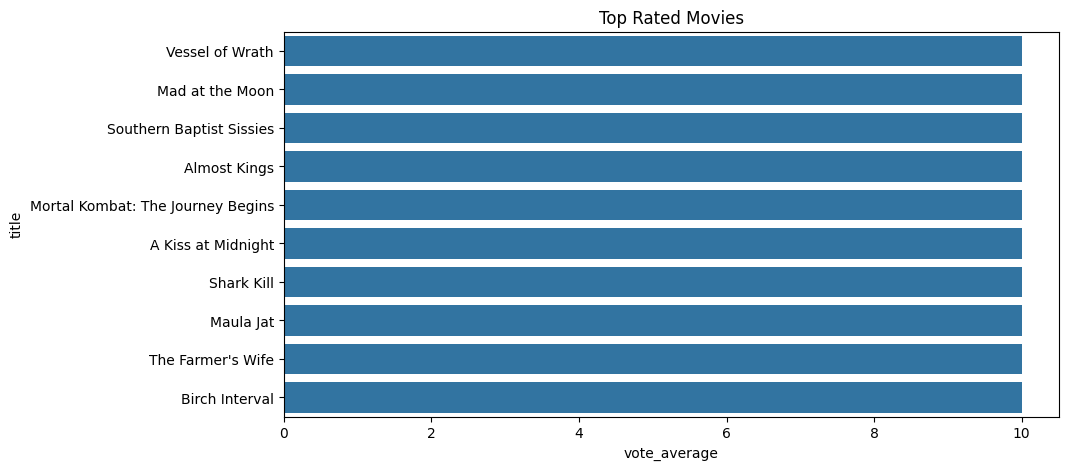

In [33]:
top=final_movies.sort_values(
    by='vote_average',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x='vote_average',
    y='title',
    data=top
)

plt.title("Top Rated Movies")
plt.show()